##### ***词嵌入***
###### 在之前我们使用独热编码来表示词，然而这种机制并不是个好选择，其中主要原因是独热编码不能准确表达不同词之间的相似度，比如常用余弦相似度来表达两个向量的相似度，而对于使用独热编码表示的词，余弦相似度为0，所以它不能编码词之间的相似度。其中，余弦相似度的数学表示如下：
$$\frac{x^Ty}{\parallel{x}\parallel \parallel{y}\parallel}\in[-1, 1].$$
##### ***word2vec***
###### 为了解决上述问题，word2vec被提出，它将每个词映射到一个固定长度的向量，这些向量能更好地表达不同词之间的相似性和类比关系。其中有两个模型：跳元模型和连续词袋。对于在语义上有意义的表示，他们的训练是依赖于条件概率，条件概率可以被看作使用语料库中一些词来预测另一些单词。由于是不带标签的数据，所以跳元模型和连续词袋都是自监督模型。
##### ***跳元模型(skip-gram)***
###### 简单来说跳元模型假设一个词可以用来在文本序列中生成其周围的单词，以文本序列“the”“man”“loves”“his”“son”为例。假设中心词选择“loves”，并将上下文窗口设置为2，给定中心词“loves”，跳元模型考虑生成上下文词“the”“man”“him”“son”的条件概率：
$$P("the", "man", "his", "son"|"loves").$$
###### 如果进一步假设上下文的词是给定中心词的情况下独立生成的，那么上述情况就可以写成：
$$P("the"|"loves")P("man"|"loves")P("his"|"loves")P("son"|"loves").$$
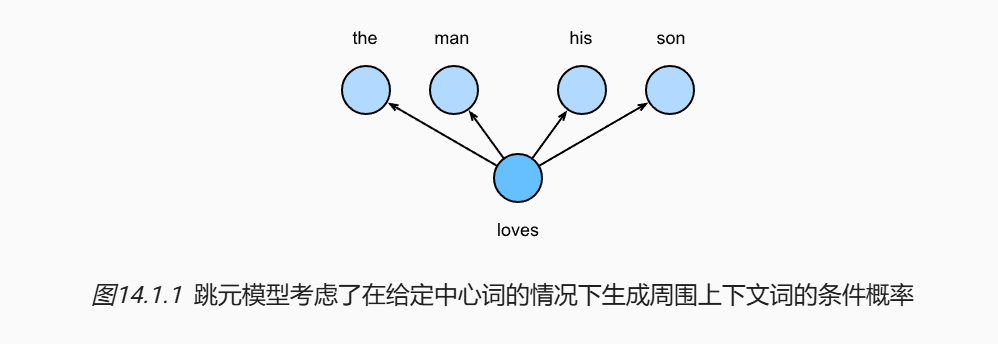
###### 在跳元模型中，每个词都有两个d维向量表示来计算条件概率。更具体来说分别用$v_i$和$u_i$表示用作中心词和上下文词的向量，而$w_c$和$w_o$表示中心词和上下文词。所以可以得到如下公式
$$P(w_o|W_c) = \frac{exp(u_o^Tv_c)}{\sum_{i\in V}exp(u_i^Tv_c)}$$
###### 其中$V$表示词表索引集，给定长度为T的文本序列，其中时间步t处的词表示为$w^{(t)}$。假设上下文词是在给定中心词的情况下独立生成的，那么对于上下文窗口m，跳元模型的似然函数是在给定任何中心词的情况下生成所有上下文词的概率：
$$\prod_{t=1}^T\prod_{-m\leq j\leq m, j\neq 0}P(w^{(t+j)}|w^{(t)}).$$
###### 在训练中我们可以通过最大化它的似然函数来学习模型参数，这相当于最小化它的对数似然函数。
$$-\prod_{t=1}^T\prod_{-m\leq j\leq m, j\neq 0}\log P(w^{(t+j)}|w^{(t)}).$$
###### 当我们使用随机梯度下降来最小化损失时，在每次迭代中可以随机抽样一个较短的子序列来计算该子序列的梯度，以更新模型，而为了计算梯度，我们需要获得对数条件概率关于中心词向量和上下文词向量的梯度。具体公式如下：
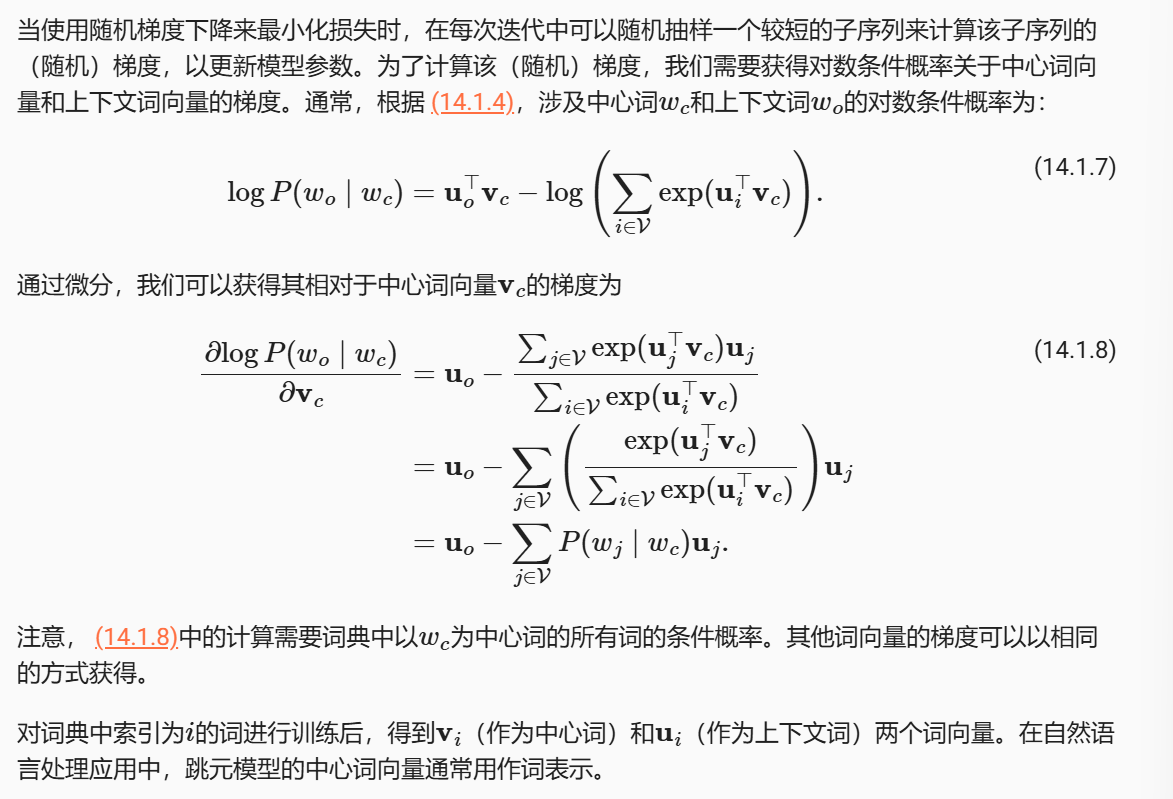
##### ***连续词袋模型(CBOW)***
###### CBOW模型类似于跳元模型，其主要区别在于CBOW假设中心词是基于其在文本序列中的周围上下文词生成的，也就是说反过来用周围的词生成中心词。
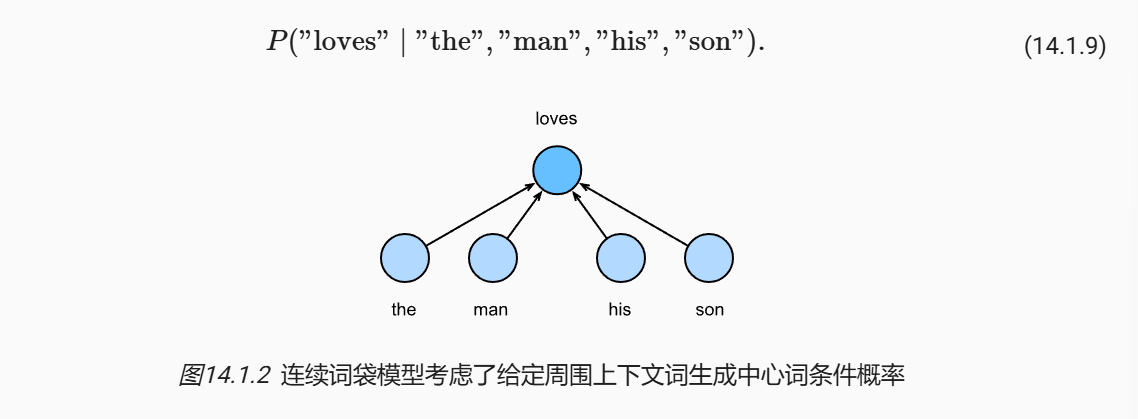
###### 由于CBOW模型中存在多个上下文词，所以在计算条件概率时需要取平均，具体公式如下：
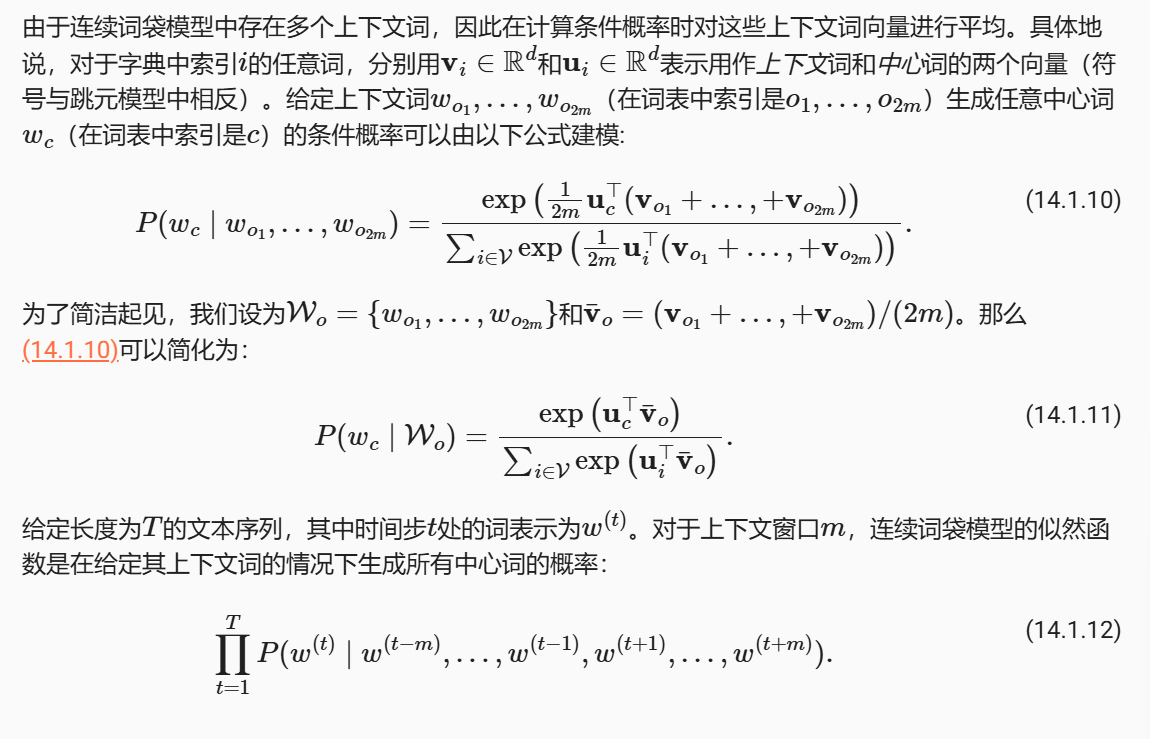
###### 对于它的训练与跳元模型几乎一致，也是最大化似然估计等价于最小化对数似然函数。
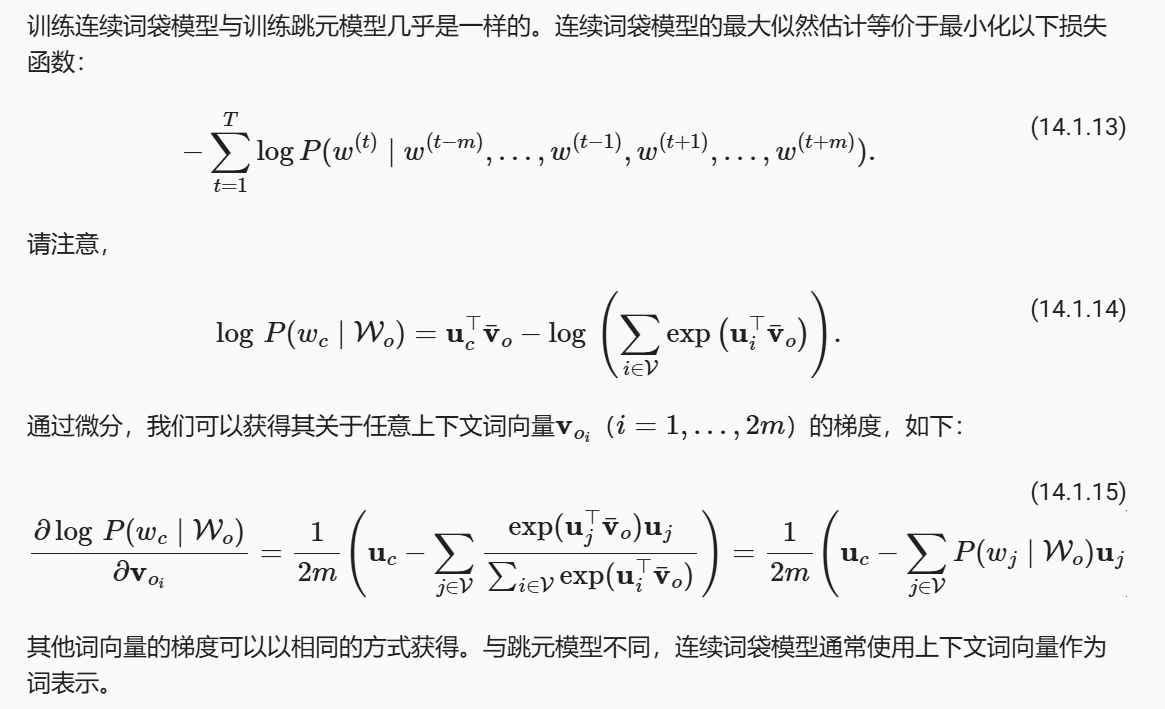